In [ ]:
# =============================================================================
# STEP 1: IMPORT LIBRARIES
# =============================================================================
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt

import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
# =============================================================================
# STEP 2: LOAD DATA
# =============================================================================
df = pd.read_excel(r"C:\Users\Shreya Verma\Documents\Projects\02_Customer Segmentation\marketing_campaign.xlsx")
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
# =============================================================================
# STEP 3: RFM FEATURE ENGINEERING
# =============================================================================
# Recency — already exists in dataset (lower = better)

# Frequency — total number of purchases across all channels
df['Frequency'] = (
    df['NumWebPurchases'] + 
    df['NumCatalogPurchases'] + 
    df['NumStorePurchases'] + 
    df['NumDealsPurchases']
)

# Monetary — total amount spent across all product categories
df['Monetary'] = (
    df['MntWines'] + 
    df['MntFruits'] + 
    df['MntMeatProducts'] + 
    df['MntFishProducts'] + 
    df['MntSweetProducts'] + 
    df['MntGoldProds']
)

# Preview RFM features
df[['Recency', 'Frequency', 'Monetary']].describe().round(2)

,Recency,Frequency,Monetary
count,2240.00,2240.00,2240.00
mean,49.11,14.86,605.80
std,28.96,7.68,602.25
min,0.00,0.00,5.00
25%,24.00,8.00,68.75
50%,49.00,15.00,396.00
75%,74.00,21.00,1045.50
max,99.00,44.00,2525.00


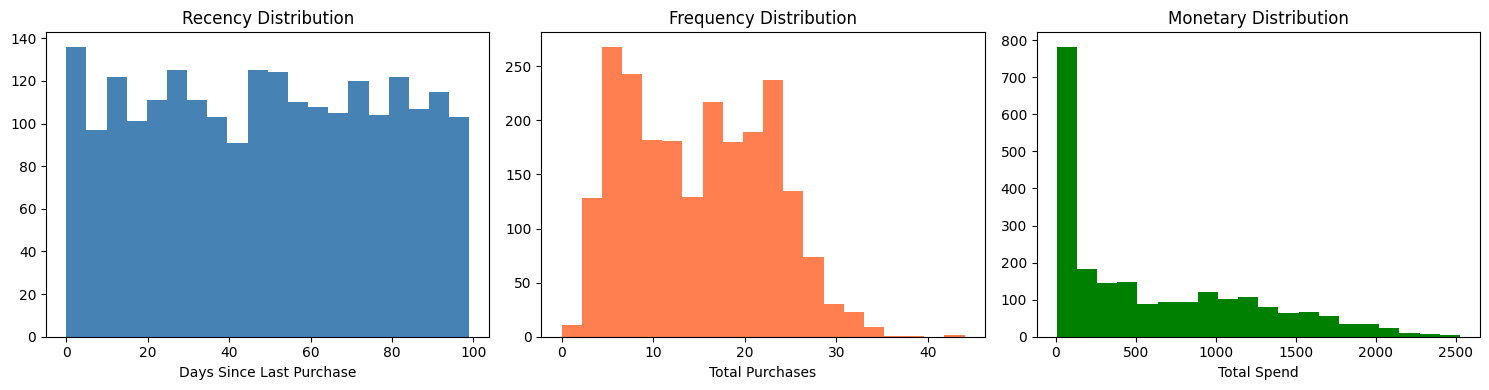

In [4]:
# =============================================================================
# STEP 4: RFM DISTRIBUTION PLOTS
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['Recency'], bins=20, color='steelblue')
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days Since Last Purchase')

axes[1].hist(df['Frequency'], bins=20, color='coral')
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Total Purchases')

axes[2].hist(df['Monetary'], bins=20, color='green')
axes[2].set_title('Monetary Distribution')
axes[2].set_xlabel('Total Spend')

plt.tight_layout()
plt.show()

In [5]:
# =============================================================================
# STEP 5: DATA CLEANING & PREPROCESSING
# =============================================================================
# Drop non-numeric datetime column
df_cleaned = df.drop(['Dt_Customer'], axis=1)

# Encode categorical columns
df_cleaned = pd.get_dummies(df_cleaned, columns=['Education', 'Marital_Status'], drop_first=True)

# Handle missing values - fill with median
df_cleaned = df_cleaned.fillna(df_cleaned.median())

In [6]:
# =============================================================================
# STEP 6: SCALING
# =============================================================================
scaler = StandardScaler()
scaled_df = scaler.fit_transform(df_cleaned)

In [7]:
# =============================================================================
# STEP 7: PCA - DIMENSIONALITY REDUCTION
# =============================================================================
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_df)

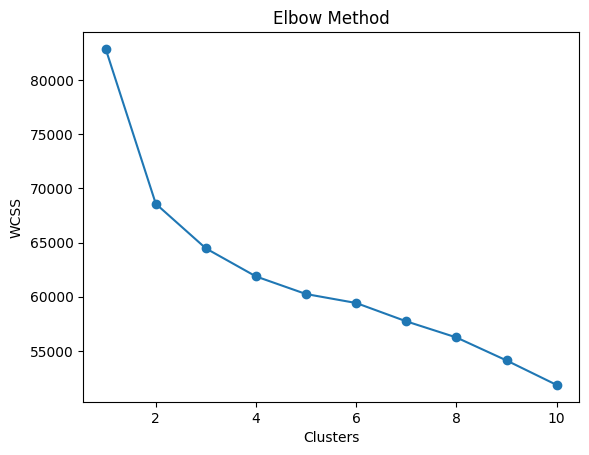

In [8]:
# =============================================================================
# STEP 8: ELBOW METHOD - OPTIMAL CLUSTER SELECTION
# =============================================================================
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Clusters')
plt.ylabel('WCSS')
plt.show()

In [9]:
# =============================================================================
# STEP 9: K-MEANS CLUSTERING
# =============================================================================
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_df)

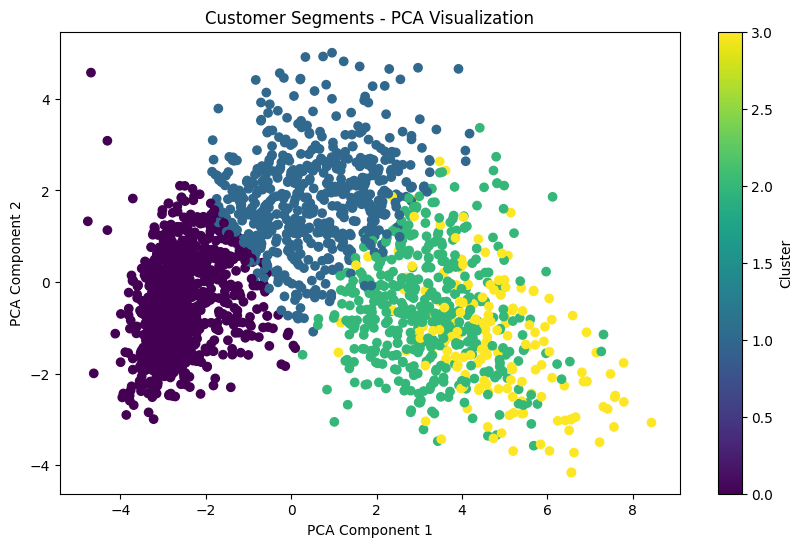

In [10]:
# =============================================================================
# STEP 10: PCA CLUSTER VISUALIZATION
# =============================================================================
plt.figure(figsize=(10,6))
plt.scatter(pca_result[:,0], pca_result[:,1], 
            c=df['Cluster'], cmap='viridis')
plt.title('Customer Segments - PCA Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()

In [11]:
# =============================================================================
# STEP 11: CLUSTER PROFILING
# =============================================================================
df.groupby('Cluster')[['Income', 'MntWines', 
'MntFruits', 'Recency', 'Frequency', 'Monetary']].mean().round(2)

,Income,MntWines,MntFruits,Recency,Frequency,Monetary
Cluster,,,,,,
0,34620.93,38.20,4.93,49.51,7.72,93.19
1,56541.20,433.95,18.76,47.55,20.58,675.39
2,74170.29,505.64,71.07,50.04,21.14,1253.81
3,81723.27,880.18,55.84,49.44,20.70,1624.47


In [14]:
cluster_labels = {
    0: 'Budget Conscious',        # Lowest income (34.6K), lowest spend
    1: 'Emerging Shoppers',       # Mid income (56.5K), growing engagement
    2: 'Affluent Selectives',     # High income (74.2K), highest frequency
    3: 'Premium Loyalists'        # Highest income (81.7K), highest spend
}

df['Segment'] = df['Cluster'].map(cluster_labels)
df['Segment'].value_counts()

Segment
Budget Conscious       1018
Emerging Shoppers       579
Affluent Selectives     468
Premium Loyalists       175
Name: count, dtype: int64

In [15]:
# =============================================================================
# STEP 12: EXPORT RESULTS
# =============================================================================
df.to_csv("segmented_customers.csv", index=False)